# SHAP Explainability

## Objective

Explain why the machine learning model predicts customer churn using SHAP values.

SHAP provides feature-level explanations for every prediction.

# Uncomment if SHAP is not installed

# !pip install shap

In [2]:
import sys

print(sys.executable)

C:\Users\amanr\anaconda3\python.exe


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

In [7]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

In [8]:
with open("../models/best_model.pkl","rb") as file:
    model = pickle.load(file)

In [9]:
explainer = shap.Explainer(model, X_train)

explainer

Background dataset has 5625 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


In [10]:
shap_values = explainer(X_test)

shap_values

.values =
array([[-0.02588968575552295, -1.3236574389114353, -0.07046145211006044,
        ..., 0.0346637968742513, -0.15037778682885874,
        -0.014601697542257592],
       [-0.02588968575552295, 1.4439415487602423, -0.09509335469643446,
        ..., -0.009214427017206041, -0.15037778682885874,
        -0.014601697542257592],
       [-0.02588968575552295, -1.0575421516353125, 0.4586507630626284,
        ..., -0.009214427017206041, -0.15037778682885874,
        0.0549301955161119],
       ...,
       [-0.02588968575552295, 1.656833778581141, 0.46480873870922196,
        ..., -0.009214427017206041, -0.15037778682885874,
        0.0549301955161119],
       [-0.02588968575552295, -0.15275017489649462, 0.26491137541210946,
        ..., -0.009214427017206041, -0.15037778682885874,
        0.0549301955161119],
       [-0.02588968575552295, -0.844649921814414, 0.4581770726282752,
        ..., 0.0346637968742513, -0.15037778682885874,
        -0.014601697542257592]], shape=(1407, 7061), dty

In [11]:
print(shap_values.values.shape)

(1407, 7061)


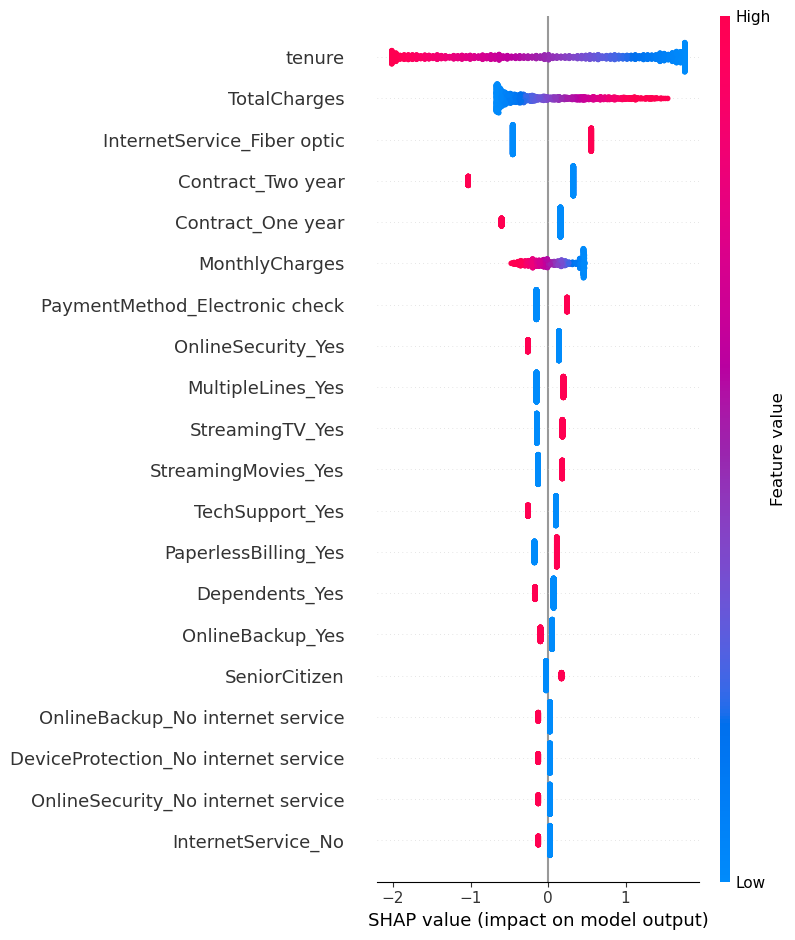

In [17]:
shap.summary_plot(
    shap_values,
    X_test
)

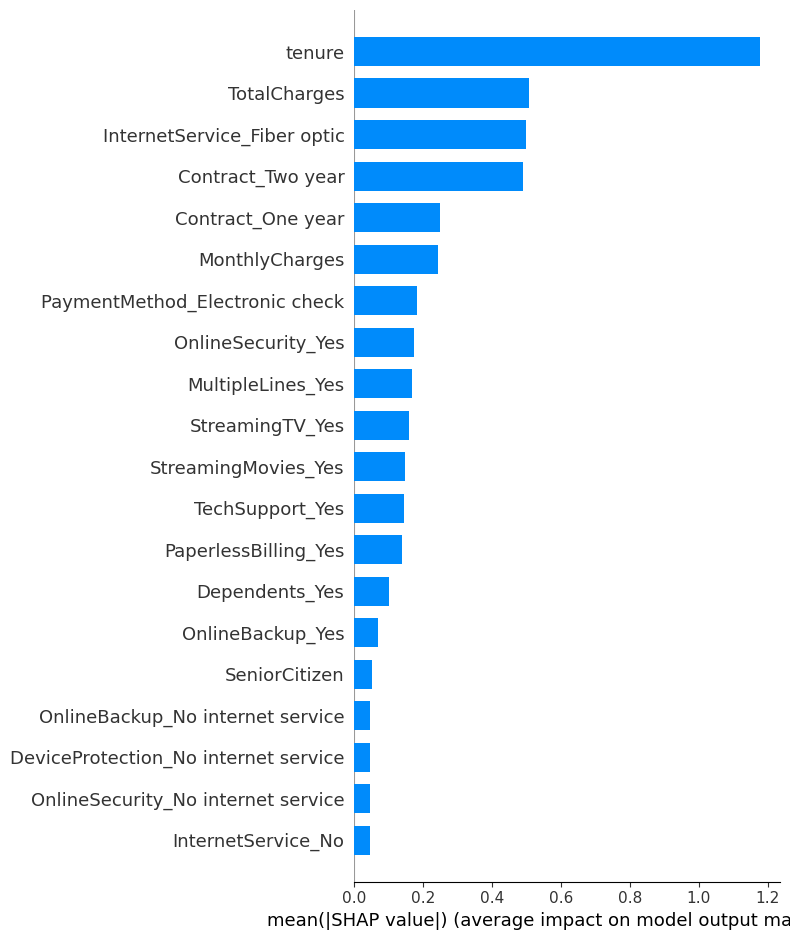

In [18]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

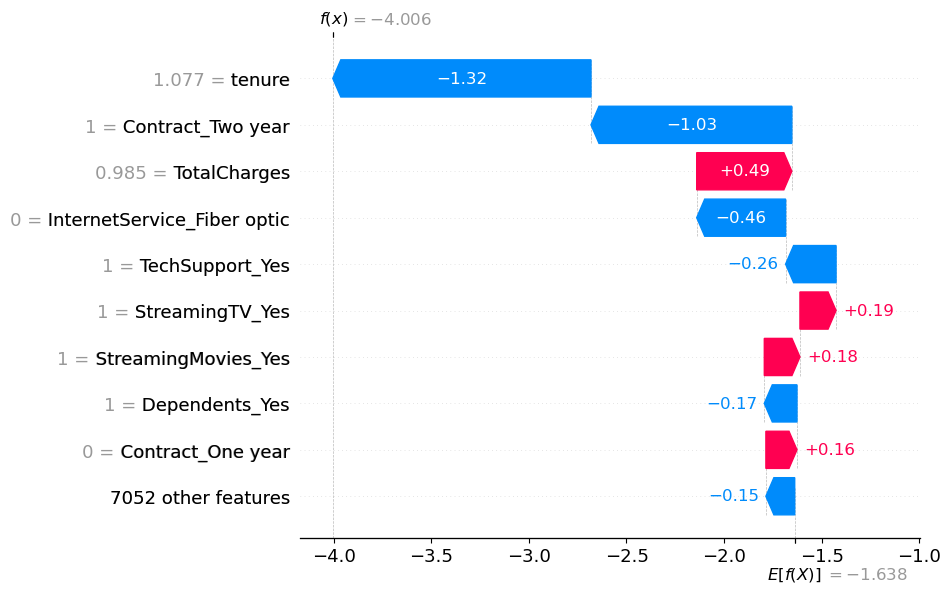

In [19]:
shap.plots.waterfall(
    shap_values[0]
)

In [20]:
shap.initjs()

shap.plots.force(
    shap_values[0]
)

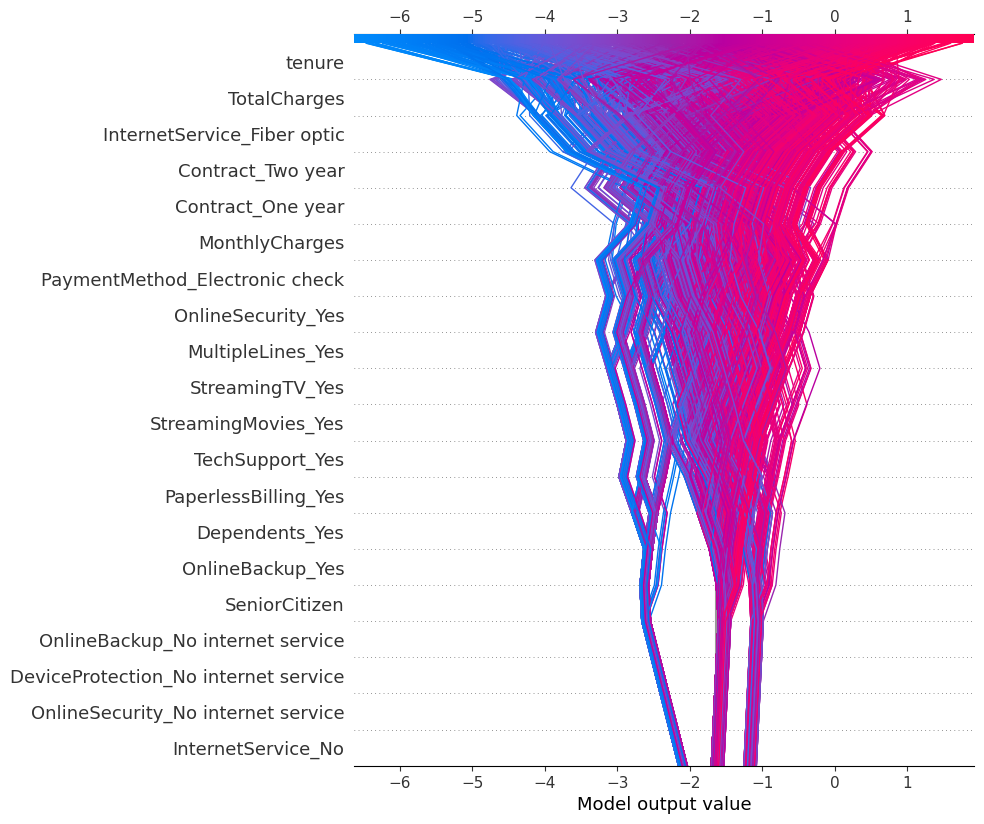

In [21]:
shap.decision_plot(
    explainer.expected_value,
    shap_values.values,
    X_test
)

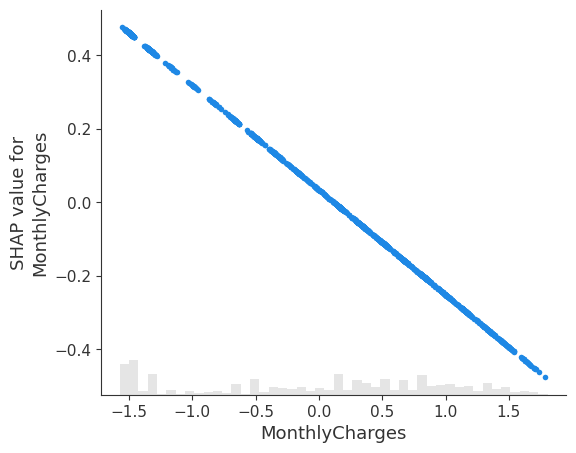

In [22]:
shap.plots.scatter(
    shap_values[:, "MonthlyCharges"]
)

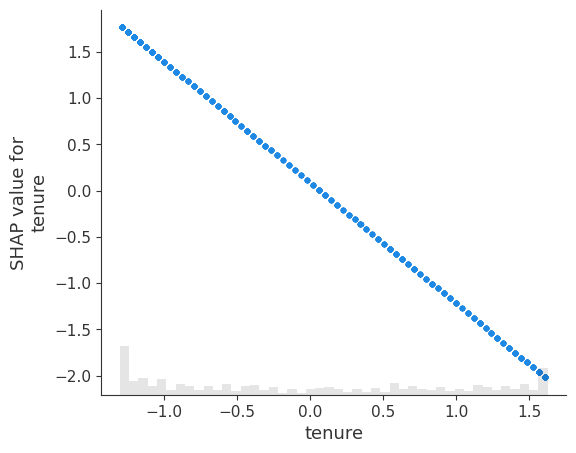

In [23]:
shap.plots.scatter(
    shap_values[:, "tenure"]
)

In [24]:
importance = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({

    "Feature": X_test.columns,
    "Importance": importance

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
1,tenure,1.177381
3,TotalCharges,0.508399
7041,InternetService_Fiber optic,0.499911
7056,Contract_Two year,0.488872
7055,Contract_One year,0.250184
2,MonthlyCharges,0.243792
7059,PaymentMethod_Electronic check,0.181294
7044,OnlineSecurity_Yes,0.174164
7040,MultipleLines_Yes,0.169157
7052,StreamingTV_Yes,0.159972


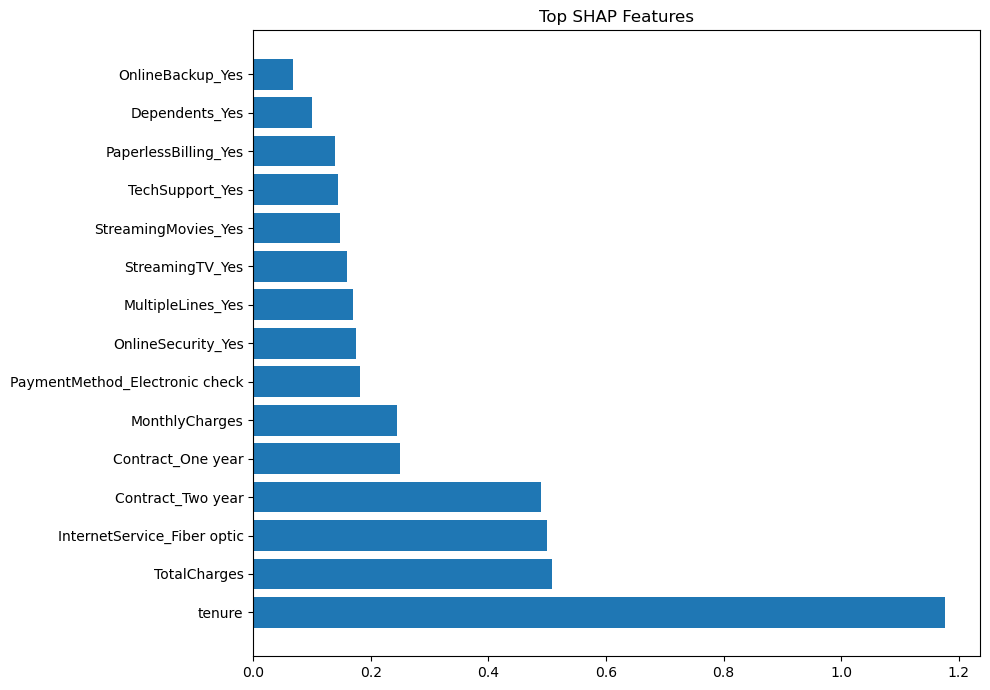

In [25]:
plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"][:15],
    importance_df["Importance"][:15]
)

plt.title("Top SHAP Features")

plt.tight_layout()

plt.show()

In [26]:
importance_df.to_csv(
    "../data/shap_feature_importance.csv",
    index=False
)

print("Saved!")

Saved!


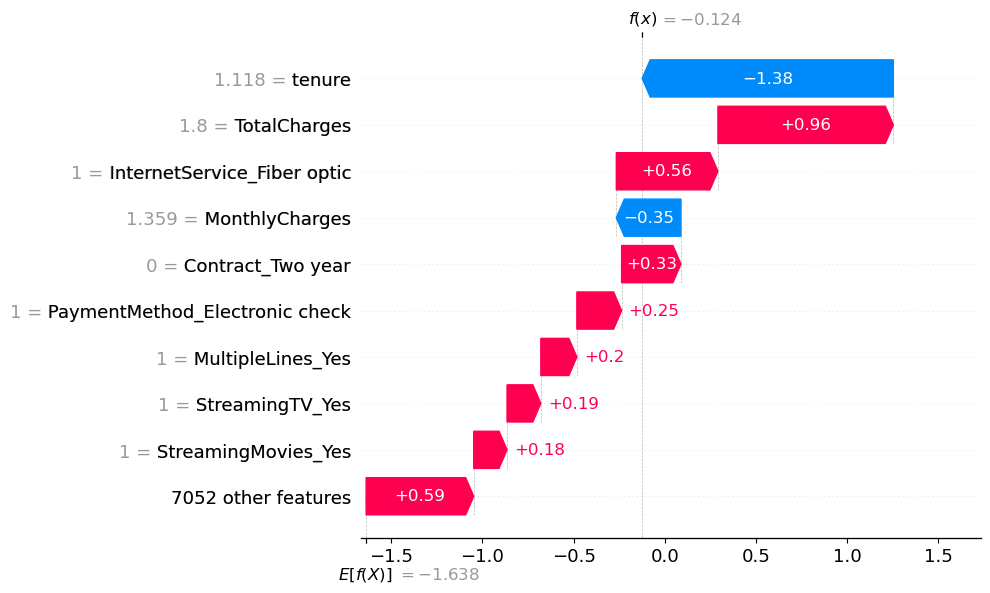

In [27]:
customer = 5

shap.plots.waterfall(
    shap_values[customer]
)

In [28]:
prediction = model.predict(
    X_test.iloc[[customer]]
)

prediction

array([0])

In [29]:
prob = model.predict_proba(
    X_test.iloc[[customer]]
)

prob

array([[0.53098389, 0.46901611]])

# Business Insights

SHAP explains why the model predicts churn.

Positive SHAP values increase churn probability.

Negative SHAP values decrease churn probability.

These explanations help business teams trust the model and take targeted retention actions.

# Conclusion

The model is no longer a black box.

Using SHAP, we can explain:

- Which feature influenced prediction
- How much it influenced
- Whether it increased or decreased churn

This improves transparency and business trust.